# NB3 

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

Let's import `jour_df` from the pickle `2023-03-21_NB2_jour_df_part3.pkl` and `papers_df` from the pickle `2023-03-21_NB2_papers_df_part4.pkl`

In [2]:
papers_df = pd.read_pickle('2023-03-21_NB2_papers_df_part4.pkl')
jour_df = pd.read_pickle('2023-03-21_NB2_jour_df_part3.pkl')

In [3]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,nature,journal,17.897,1276.0,United Kingdom,Western Europe
1,science,journal,14.589,1229.0,United States,Northern America
2,proceedings of the national academy of science...,journal,4.184,805.0,United States,Northern America
3,chemical reviews,journal,18.718,745.0,United States,Northern America
4,physical review letters,journal,3.246,647.0,United States,Northern America


In [4]:
papers_df.head(5)

,Cites,Authors,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015,science,1,Journal article,4186,523.25,523,8,0
1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018,nature,2,Journal article,2319,463.80,258,9,0
2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005,nature materials,3,Journal article,2163,120.17,309,7,0
3,1951,"H Tan, A Jain, O Voznyy, X Lan, FP García de A...",Efficient and stable solution-processed planar...,2017,science,4,Journal article,1951,325.17,279,7,0
4,1897,"G Konstantatos, I Howard, A Fischer, S Hooglan...",Ultrasensitive solution-cast quantum dot photo...,2006,nature,5,Journal article,1897,111.59,271,7,0


Let's attempt to merge `papers_df` with `jour_df` on the publication titles. We will use a left join in order to preserve the columns in the `papers_df` that weren't able to join to `jour_df` for investigation. We will call the joined data frame `join_df`.

In [5]:
def get_merge_per():
    global papers_df, jour_df, entry_goal

    join_df = pd.merge(left = papers_df, right = jour_df, left_on = 'Source', right_on = 'Title', how = 'left')

    non_nulls_per = (1 - join_df['Title_y'].isna().sum()/join_df['Title_y'].isna().count())
    entries_left = (join_df['Title_y'].isna() == False).sum()
    diff = entry_goal - entries_left
    
    print("{:.2%} of the entries merged!".format(non_nulls_per))
    print(f'{round(diff)} rows left to go!')
    return join_df

In [6]:
entry_goal = papers_df.shape[0]*0.85
print('The number of entries to aim for is', round(entry_goal))

The number of entries to aim for is 17554


In [7]:
join_df = get_merge_per()

79.53% of the entries merged!
1129 rows left to go!


Luckily, almost 80% of the entries so we're starting off strong! Let's investigate the values in `Source` that didn't merge with `Title` to see where we could make some formatting adjustments to merge more rows. Note, the cell below was executed multiple times to take in a different sample of 10 values to get an idea of the title variations, so the title variations discussed below it may differ from what would be initially outputted in the cell.

In [8]:
# I executed this line multiple times to get an idea of some of the title variations
join_df['Source'][join_df['Title_y'].isna()].sample(10).value_counts()

journal of vacuum science and technologysection bmicroelectronics              1
organic nanophotonics                                                          1
ieee international electron devices meeting iedm                               1
journal of experimental and theoretical physics letters                        1
acs earth and space chemistry                                                  1
applied physics a                                                              1
science  eabd                                                                  1
japanese journal of applied physics s fv                                       1
optical nanostructures and advanced materials for photovoltaics pwc            1
international journal of science and engineering applications special issue    1
Name: Source, dtype: int64

One pattern that was noticed was that there would often been variations of publications, notably `science` and `science advances` that were followed by a code, usually beginning with `ea`. Let's look at the distribution of those variables specifically.

In [9]:
join_df['Source'][join_df['Source'].str.contains(r'^science', regex = True)].value_counts()

science                                          83
science advances                                 16
science china chemistry                          14
science bulletin                                  9
science china materials                           7
science of advanced materials                     7
science and technology of advanced materials      5
science advances  eabq                            4
science advances  eabb                            4
science advances  eabj                            3
science advances  eaay                            3
science advances  eabf                            3
science advances  eabc                            3
science advances  eaao                            2
science advances  eabg                            2
science advances  eaat                            2
science advances  eabd                            2
science advances  eaau                            2
science advances  eaav                            2
science adva

Let's pull up the titles of a paper that has a suffix `eabq`

In [10]:
papers_df['Title'][papers_df['Source'] == 'science advances  eabq'].values[0]

'Momentum-matching and band-alignment van der Waals heterostructures for high-efficiency infrared photodetection'

From that paper's [citation](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=Momentum-matching+and+band-alignment+van+der+W&btnG=#d=gs_cit&t=1679502207047&u=%2Fscholar%3Fq%3Dinfo%3AH-GM87rXWl0J%3Ascholar.google.com%2F%26output%3Dcite%26scirp%3D0%26hl%3Den) it appears that the `eabq` was accidentally pulled from the page number and appended to the title. The page number beginning with `ea` seems to be a consistent trend across both papers published in `science` and `science advances` so let's reformat those names so that those suffixes no longer exist. We will store the results in `test_df` to inspect before overwriting `papers_df`, and consequently, `jour_df`.

In [11]:
def remove_pattern(val, pattern, method = 'no_space'):
    
    assert isinstance(val, str), 'Input value must be a string'
    assert isinstance(pattern, str), 'Input pattern must be a string'
    
    if method == 'no_space':
        return re.sub(pattern, '', val).strip()
    elif method == 'one_space':
        return re.sub(pattern, ' ', val).strip()

In [12]:
test_df = join_df.assign(Source = join_df['Source'].apply(remove_pattern, pattern = r'\s*ea..$', method = 'no_space'))
test_df['Source'][test_df['Source'].str.contains(r'^science', regex = True)].value_counts()

science                                          90
science advances                                 59
science china chemistry                          14
science bulletin                                  9
science china materials                           7
science of advanced materials                     7
science and technology of advanced materials      5
science  aac                                      1
science bulletin s                                1
science  aad                                      1
science and technology                            1
science of the total environment                  1
science china physics mechanics and astronomy     1
science robotics                                  1
Name: Source, dtype: int64

It look like our method worked! We can apply the same technique to remove the `s` suffix from `science bulletin s` since that looks to just be appended on accident. But first, let's investigate the origins of the `aad` and `aac` suffixes.

In [13]:
print('Here is a paper title:')
papers_df['Title'][papers_df['Source'] == 'science  aac'].values[0]

Here is a paper title:


'Building devices from colloidal quantum dots'

Like before, based on the paper's [citation](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=%27Building+devices+from+colloidal+quantum+dots%27&btnG=#d=gs_cit&t=1679503521305&u=%2Fscholar%3Fq%3Dinfo%3AiNGwANcHelAJ%3Ascholar.google.com%2F%26output%3Dcite%26scirp%3D0%26hl%3Den) it appears that the `aad` and `aac` suffixes were incorrectly appended from the page numbers. Let's fix the formatting to remove those suffixes along with `s`.

In [14]:
# Creating a list of all the patterns to apply
pattern_list = [r'\s*ea..$', r'\s*aa.$', r'\ss$']

test_df = join_df.copy()
for i in pattern_list:
    test_df = test_df.assign(Source = test_df['Source'].apply(remove_pattern, pattern = i, method = 'no_space'))

test_df['Source'][test_df['Source'].str.contains(r'^science', regex = True)].value_counts()

science                                          92
science advances                                 59
science china chemistry                          14
science bulletin                                 10
science china materials                           7
science of advanced materials                     7
science and technology of advanced materials      5
science and technology                            1
science of the total environment                  1
science china physics mechanics and astronomy     1
science robotics                                  1
Name: Source, dtype: int64

The formatting was successful! Let's apply it to `papers_df` and re-join the data frames.

In [15]:
# Creating a list of all the patterns to apply
pattern_list = [r'\s*ea..$', r'\s*aa.$', r'\ss$']

for i in pattern_list:
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(remove_pattern, pattern = i, method = 'no_space'))

In [16]:
join_df = get_merge_per()

79.83% of the entries merged!
1067 rows left to go!


The number of entires that merged only went up by about 0.2%. Let's investigate the values with the most entires that did not join.

In [17]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

bulletin of the american physical society    91
journal of materials chemistry               73
journal of physics d applied physics         68
chemistrya european journal                  67
physica status solidi a                      64
journal of nanoscience and nanotechnology    55
angewandte chemie                            54
physica status solidi b                      48
applied physics a                            44
mrs online proceedings library opl           41
Name: Source, dtype: int64

The most common values is `bulletin of the american physical society`. Let's see if there are any values in the `jour_df` that are similar.

In [18]:
jour_df['Title'][jour_df['Title'].str.contains('physical society')]

462     journal of the physical society of japan
2001      journal of the korean physical society
Name: Title, dtype: object

There were no values in `jour_df` that matched. Further investigation into this value reveled that the Bulletin of the American Physical Society is [a collection of conference proceedings](https://www.aps.org/meetings/baps/index.cfm). In general, we want to avoid including conference proceedings since their metrics are not tracked as often as conference papers, journal articles and books. Therefore, let's remove entires from `papers_df` from conference proceedings.

In [19]:
conf_df = papers_df['Source'][papers_df['Type'] == 'Conference paper']

pro_per = conf_df.str.contains('proceedings').sum()/conf_df.str.contains('proceedings').count()
conf_per = conf_df.str.contains('conference').sum()/conf_df.str.contains('conference').count()

print('{:0.2%} of the Conference papers in paper_df contain the token "proceedings" in their Source value'.format(pro_per))
print('{:0.2%} of the Conference papers in paper_df contain the token "conference" in their Source value'.format(conf_per))

31.86% of the Conference papers in paper_df contain the token "proceedings" in their Source value
59.38% of the Conference papers in paper_df contain the token "conference" in their Source value


In [20]:
pro_sum = jour_df['Title'].str.contains('proceedings').sum()
conf_sum = jour_df['Title'].str.contains('conference').sum()

print(f'There are {pro_sum} publication titles in jour_df that contain the token "proceedings"')
print(f'There are {conf_sum} publication titles in jour_df that contain the token "conference"')

There are 123 publication titles in jour_df that contain the token "proceedings"
There are 66 publication titles in jour_df that contain the token "conference"


From the investigation, it looks like the majority ( > 59%) of the conference papers in `papers_df` contain the token `conference`, and 31.86% contain the token `proceedings`. Additionally, there do look to be a number of entires in `jour_df` containing `proceedings` and `conference` in the title, suggesting there may be reason to further streamline the formatting of these titles to be able to join the entries.

Since a variation of `bulletin of the american physical society` is not in `jour_df`, let's remove those entires from `papers_df`.

In [21]:
papers_df = papers_df.drop(papers_df[papers_df['Source'] == 'bulletin of the american physical society'].index)

In [22]:
join_df = get_merge_per()

80.19% of the entries merged!
1067 rows left to go!


In [23]:
null_df = join_df[join_df['Title_y'].isna()]

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initiate 
bagofwords = CountVectorizer(stop_words = 'english')

# 2. Fit 
bagofwords.fit(null_df['Source'])

# 3. Transform
small_transformed = bagofwords.transform(conf_df.values)

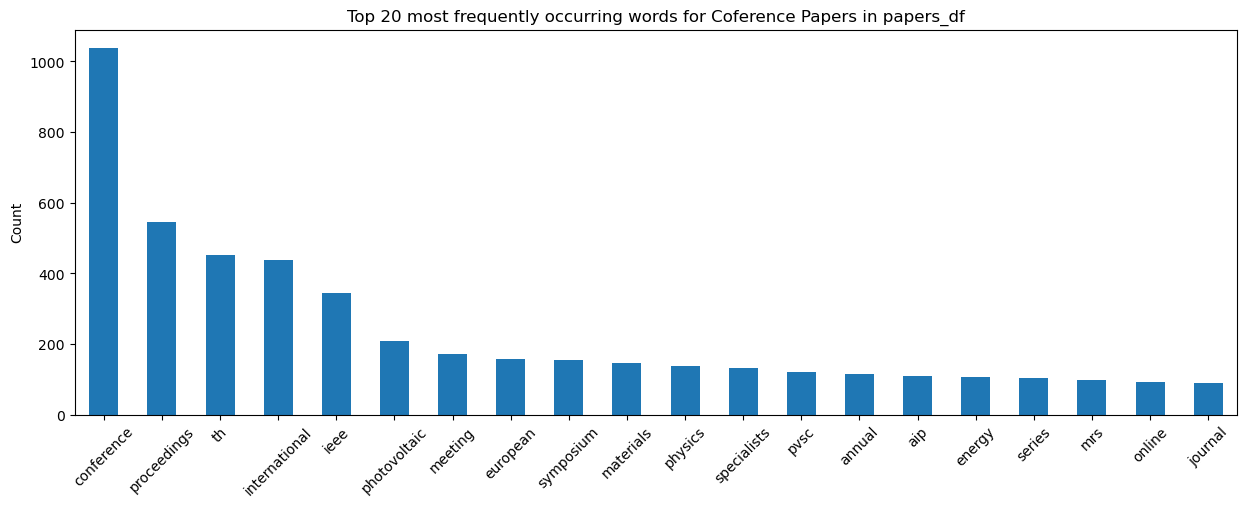

In [25]:
word_counts = pd.DataFrame(
    {"counts": small_transformed.toarray().sum(axis=0)},
    index=bagofwords.get_feature_names_out()
).sort_values("counts", ascending=False)

word_counts.head(20).plot(kind="bar", figsize=(15, 5), legend=False)
plt.title("Top 20 most frequently occurring words for Coference Papers in papers_df")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

From this analysis, we see that `conference` and `proceedings` are the two most frequently occurring words, followed by `th` which appears to be `the` mis-spelled, `international`, which could refer to the conference being an international meeting, and `ieee`, which is an acronym for Institute of Electrical and Electronics Engineers. There are also instances of other organization acronyms, like `mrs` for the Materials Research Society, and `aip` for the American Institute of Physics.

Let's search for values in `jour_df` that contain those organization acronyms and compare those to the values in `papers_df` to discern how to reformat the data.

In [26]:
jour_df['Title'][jour_df['Title'].str.contains('ieee')].value_counts()

ieee transactions on industrial electronics                                     1
ieee transactions on components packaging and manufacturing technology          1
conference record of the ieee photovoltaic specialists conference               1
ieeeacm transactions on audio speech and language processing                    1
proceedings of the ieee vlsi test symposium                                     1
                                                                               ..
ieee transactions on computeraided design of integrated circuits and systems    1
ieee control systems                                                            1
ieee vehicular technology conference                                            1
ieee transactions on circuits and systems ii express briefs                     1
ieee international conference on plasma science                                 1
Name: Title, Length: 185, dtype: int64

In [27]:
null_df['Source'][null_df['Source'].str.contains('ieee')].value_counts()

ieee th photovoltaic specialists conference pvsc                       41
th ieee photovoltaic specialists conference                            30
th ieee photovoltaic specialists conference pvsc                       23
ieee th photovoltaics specialists conference pvsc                      19
ieee th photovoltaic specialist conference pvsc                        16
                                                                       ..
proceedings of ieee st world conference on photovoltaic energy          1
conference record of the twenty sixth ieee photovoltaic specialists     1
ieee international reliability physics symposium xt xt                  1
th ieee semiconductor interface specialists conference sisc             1
ieee international ultrasonics symposium ius                            1
Name: Source, Length: 128, dtype: int64

It looks like there are some suffixes in the publication titles for `papers_df` that don't appear in the values for `jour_df`. Let's see the percentage of times those specific suffixes appear in strings that also contain `ieee`.

In [28]:
for i in ['pvsc', 'xt xt', 'sisc', 'ius']:
    both = null_df['Source'][null_df['Source'].str.contains('ieee') & null_df['Source'].str.contains(i)].count()
    only = null_df['Source'][null_df['Source'].str.contains(i)].count()
    per = only/both

    print('{:0.1%} of the publication titles that have the token "{}" also have the token "iee"'.format(per, i))

100.0% of the publication titles that have the token "pvsc" also have the token "iee"
100.0% of the publication titles that have the token "xt xt" also have the token "iee"
100.0% of the publication titles that have the token "sisc" also have the token "iee"
100.0% of the publication titles that have the token "ius" also have the token "iee"


Since these suffixes exclusively appear in strings that also contain `ieee`, let's remove those from the values in `papers_df`.

In [29]:
test_df = null_df.copy()
for i in ['pvsc', 'xt xt', 'sisc', 'ius', 'edtm', 'th\s']:
    test_df = test_df.assign(Source = test_df['Source'].apply(remove_pattern, pattern = i, method = 'no_space'))

# Remove double spacing
test_df = test_df.assign(Source = test_df['Source'].apply(remove_pattern, pattern = '  ', method = 'one_space'))
test_df['Source'][test_df['Source'].str.contains('ieee')].value_counts()

ieee photovoltaic specialists conference                            94
ieee photovoltaics specialists conference                           19
ieee photovoltaic specialist conference                             16
ieee world conference on photovoltaic energy conversion wcpeca      16
ieee nd photovoltaic specialist conference                          12
                                                                    ..
conference record of the twenty sixieee photovoltaic specialists     1
ieee international reliability physics symposium                     1
ieee semiconductor interface specialists conference                  1
ieee international conference on integrated circuit design and       1
ieee electron devices technology and manufacturing conference        1
Name: Source, Length: 122, dtype: int64

The test run shows that removing the suffixes and `th` reduced the number of unique formats by 7, but there are still some more formatting inconsistencies, such as `photovoltaic` vs the plural `photovoltaics`. However, let's just find the format of the `jour_df` entry that best matches the sources with the top value counts.

In [30]:
print('Contains "ieee photovoltaic"')
jour_df['Title'][jour_df['Title'].str.contains('ieee photovoltaic')].value_counts()

Contains "ieee photovoltaic"


conference record of the ieee photovoltaic specialists conference    1
Name: Title, dtype: int64

In [31]:
def replace_word(val, match_word, out_word):
    match_check = all(i in val for i in match_word)
    if match_check:
        return out_word
    else:
        return val

In [32]:
test_df = null_df.copy()
test_df = test_df.assign(Source = test_df['Source'].apply(replace_word, match_word = ['ieee',  'photovoltaic', 'specialist'], out_word = 'conference record of the ieee photovoltaic specialists conference'))
test_df['Source'][test_df['Source'].str.contains('ieee')].value_counts()

conference record of the ieee photovoltaic specialists conference    159
ieee th world conference on photovoltaic energy conversion wcpeca     16
ieee international electron devices meeting iedm                       8
ieee th world conference on photovoltaic energy conference             6
ieee photonics conference ipc                                          5
                                                                    ... 
proceedings of ieee st world conference on photovoltaic energy         1
ieee international reliability physics symposium xt xt                 1
th ieee semiconductor interface specialists conference sisc            1
ieee international conference on integrated circuit design and         1
ieee international ultrasonics symposium ius                           1
Name: Source, Length: 116, dtype: int64

This seems to work well, we were able to reduce around 12 unique titles in total. Let's apply the same method to `papers_df`.

In [33]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['ieee',  'photovoltaic', 'specialist'], out_word = 'conference record of the ieee photovoltaic specialists conference'))

In [34]:
join_df = get_merge_per()

80.96% of the entries merged!
908 rows left to go!


---

In [35]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

journal of materials chemistry               73
journal of physics d applied physics         68
chemistrya european journal                  67
physica status solidi a                      64
journal of nanoscience and nanotechnology    55
angewandte chemie                            54
physica status solidi b                      48
applied physics a                            44
mrs online proceedings library opl           41
sid symposium digest of technical papers     34
Name: Source, dtype: int64

In [36]:
jour_df['Title'][jour_df['Title'].str.contains('journal of materials chemistry')]

104    journal of materials chemistry a
405    journal of materials chemistry c
692    journal of materials chemistry b
Name: Title, dtype: object

In [37]:
import re

def edit_title(row):
    '''
    
    This function takes publication titles and uses regex to edit the format of that value.
    
    '''
    title = row
    
    assert isinstance(title, str), 'Input parameter must be a string'
    
    # Encode the titles in ASCII 
    title = title.encode('ascii', 'ignore').decode('ascii')
    
    # Get rid of 'The'
    title = re.sub(r'^The\s', '', title)
    
    # Get rid of '(discontinued)'
    title = re.sub(r'\(discontinued\)', '', title)
    
    # Insert spaces in '&word' case
    title = re.sub(r'\&\+?', 'and ', title)
    
    # Get rid of special characters 
    title = re.sub(r'[!@#$%\^\*\(\)-:\.=,\+\_]', '', title)
    
    # Get rid of double spacing
    title = re.sub(r'  ', ' ', title)
    
    return title.strip().lower()

In [38]:
title = 'journal of materials chemistry'
type_ = 'journal'
SJR = 2.41
H_index = int(314)
country = 'United Kingdom'
region = 'Western Europe'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [39]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

81.31% of the entries merged!
835 rows left to go!


---

In [40]:
jour_df['Title'][jour_df['Title'].str.contains('journal of physics')]

112                   journal of physics condensed matter
242                                new journal of physics
351     journal of physics a mathematical and theoretical
611     journal of physics b atomic molecular and opti...
704            journal of physics and chemistry of solids
755     journal of physics g nuclear and particle physics
848                           american journal of physics
1042                 journal of physics conference series
1704                          canadian journal of physics
1777                           pramana journal of physics
1891                          european journal of physics
2008                         brazilian journal of physics
2207                           chinese journal of physics
2740                            indian journal of physics
2857                          romanian journal of physics
3162                           turkish journal of physics
4254                    journal of physics communications
4357          

In [41]:
print(jour_df[jour_df['Title'].str.contains('journal of physics')].loc[611, 'Title'])

journal of physics b atomic molecular and optical physics


In [42]:
null_df = join_df[join_df['Title_y'].isna()]

In [43]:
null_df['Source'][null_df['Source'].str.contains('journal of physics')].value_counts()

journal of physics d applied physics                    68
journal of physics materials                             8
journal of physics energy                                7
journal of physics condensed matter  r                   2
journal of physics f metal physics                       2
lithuanian journal of physics and technical sciences     2
journal of physics condensed matter  l                   2
journal of physics c solid state physics  l              2
journal of physics conference series online              1
armenian journal of physics                              1
journal of physics d applied physics  lt                 1
journal of physics photonics                             1
Name: Source, dtype: int64

In [44]:
test_df = null_df.copy()
test_df = test_df.assign(Source = test_df['Source'].apply(replace_word, match_word = ['journal of physics d'], out_word = 'journal of physics b atomic molecular and optical physics'))
test_df['Source'][test_df['Source'].str.contains('journal of physics')].value_counts()

journal of physics b atomic molecular and optical physics    69
journal of physics materials                                  8
journal of physics energy                                     7
journal of physics condensed matter  r                        2
journal of physics f metal physics                            2
lithuanian journal of physics and technical sciences          2
journal of physics condensed matter  l                        2
journal of physics c solid state physics  l                   2
journal of physics conference series online                   1
armenian journal of physics                                   1
journal of physics photonics                                  1
Name: Source, dtype: int64

In [45]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['journal of physics d'], out_word = 'journal of physics b atomic molecular and optical physics'))

In [46]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

81.65% of the entries merged!
766 rows left to go!


---

In [47]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

chemistrya european journal                  67
physica status solidi a                      64
journal of nanoscience and nanotechnology    55
angewandte chemie                            54
physica status solidi b                      48
applied physics a                            44
mrs online proceedings library opl           41
sid symposium digest of technical papers     34
aiche annual meeting                         32
physical reviewsection bcondensed matter     32
Name: Source, dtype: int64

In [48]:
jour_df['Title'][jour_df['Title'].str.contains('european journal')]

65               european journal of operational research
85                           chemistry a european journal
256               european journal of medicinal chemistry
321                 european journal of organic chemistry
447               european journal of inorganic chemistry
841      european journal of lipid science and technology
927                 european journal of mechanics asolids
1285                european journal of mechanics bfluids
1441                          european journal of control
1524           european journal of wood and wood products
1891                          european journal of physics
1914                european journal of wildlife research
2084            european journal of engineering education
2148                european journal of mass spectrometry
2626                   european journal of remote sensing
2655    european journal of environmental and civil en...
3164           european journal of industrial engineering
3197      cent

In [49]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['chemistrya european journal'], out_word = 'chemistry a european journal'))

In [50]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

81.98% of the entries merged!
699 rows left to go!


---

In [51]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

physica status solidi a                            64
journal of nanoscience and nanotechnology          55
angewandte chemie                                  54
physica status solidi b                            48
applied physics a                                  44
mrs online proceedings library opl                 41
sid symposium digest of technical papers           34
physical reviewsection bcondensed matter           32
aiche annual meeting                               32
physica status solidi rrlrapid research letters    29
Name: Source, dtype: int64

In [52]:
jour_df['Title'][jour_df['Title'].str.contains('physica status')].values

array(['physica status solidi b basic research',
       'physica status solidi a applications and materials science',
       'physica status solidi rapid research letters'], dtype=object)

In [53]:
null_df['Source'][null_df['Source'].str.contains('physica status')].value_counts()

physica status solidi a                                             64
physica status solidi b                                             48
physica status solidi rrlrapid research letters                     29
physica status solidi c                                             13
physica status solidiaapplied research                               6
physica status solidibbasic research                                 3
physica status solidi a applications and materials science print     1
physica status solidi c s ss                                         1
physica status solidi a applied research                             1
physica status solidirrl doi pssr                                    1
physica status solidi a  rr                                          1
Name: Source, dtype: int64

In [54]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['physica status solidi a'], out_word = 'physica status solidi a applications and materials science'))
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['physica status solidi b'], out_word = 'physica status solidi b basic research'))
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['physica status solidi', 'letters'], out_word = 'physica status solidi rapid research letters'))

In [55]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

82.68% of the entries merged!
555 rows left to go!


---

In [56]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

journal of nanoscience and nanotechnology                                      55
angewandte chemie                                                              54
applied physics a                                                              44
mrs online proceedings library opl                                             41
sid symposium digest of technical papers                                       34
physical reviewsection bcondensed matter                                       32
aiche annual meeting                                                           32
proceedings of international conference on hybrid and organic photovoltaics    24
journal of vacuum science and technology b microelectronics and nanometer      24
mrs online proceedings library                                                 20
Name: Source, dtype: int64

In [57]:
title = 'journal of nanoscience and nanotechnology'
type_ = 'journal'
SJR = 0.235
H_index = int(108)
country = 'United States'
region = 'Northern America'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [58]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

82.94% of the entries merged!
500 rows left to go!


---

In [59]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

angewandte chemie                                                              54
applied physics a                                                              44
mrs online proceedings library opl                                             41
sid symposium digest of technical papers                                       34
aiche annual meeting                                                           32
physical reviewsection bcondensed matter                                       32
proceedings of international conference on hybrid and organic photovoltaics    24
journal of vacuum science and technology b microelectronics and nanometer      24
optics express  aa                                                             20
mrs online proceedings library                                                 20
Name: Source, dtype: int64

In [60]:
jour_df['Title'][jour_df['Title'].str.contains('angewandte')].values

array(['angewandte chemie international edition',
       'zeitschrift fur angewandte mathematik und physik',
       'zamm zeitschrift fur angewandte mathematik und mechanik',
       'agit journal fur angewandte geoinformatik'], dtype=object)

In [61]:
null_df['Source'][null_df['Source'].str.contains('angewandte')].value_counts()

angewandte chemie                  54
angewandte chemiegerman edition     1
Name: Source, dtype: int64

In [62]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['angewandte'], out_word = 'angewandte chemie international edition'))

In [63]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

83.21% of the entries merged!
445 rows left to go!


---

In [64]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

applied physics a                                                              44
mrs online proceedings library opl                                             41
sid symposium digest of technical papers                                       34
physical reviewsection bcondensed matter                                       32
aiche annual meeting                                                           32
journal of vacuum science and technology b microelectronics and nanometer      24
proceedings of international conference on hybrid and organic photovoltaics    24
optics express  aa                                                             20
mrs online proceedings library                                                 20
th international conference on transparent optical networks icton              19
Name: Source, dtype: int64

In [65]:
jour_df['Title'][jour_df['Title'].str.contains('applied physics')].values

array(['applied physics letters', 'journal of applied physics',
       'journal physics d applied physics',
       'applied physics a materials science and processing',
       'japanese journal of applied physics',
       'applied physics b lasers and optics', 'applied physics express',
       'current applied physics', 'applied physics reviews',
       'epj applied physics',
       'indian journal of pure and applied physics',
       'johns hopkins apl technical digest applied physics laboratory',
       'journal of theoretical and applied physics', 'applied physics'],
      dtype=object)

In [66]:
null_df['Source'][null_df['Source'].str.contains('applied physics')].value_counts()

applied physics a                                                          44
applied physics b                                                           6
european physical journalapplied physics                                    6
japanese journal of applied physics r                                       5
japanese journal of applied physics s bf                                    2
applied physics a ss                                                        2
japanese journal of applied physics s kb                                    2
japanese journal of applied physics s g                                     1
japanese journal of applied physics s es                                    1
japanese journal of applied physics s fb                                    1
japanese journal of applied physics s cc                                    1
japanese journal of applied physics s nc                                    1
journal of applied physics  m                                   

In [67]:
match_words = [['japanese journal of applied physics'],
              ['current applied physics'],
              ['applied physics a'],
                ['applied physics b'],
               ['european physical journalapplied physics']]

out_words = ['japanese journal of applied physics',
             'current applied physics',
             'applied physics a materials science and processing',
             'applied physics b lasers and optics',
             'epj applied physics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [68]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

83.60% of the entries merged!
365 rows left to go!


---

In [69]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

mrs online proceedings library opl                                             41
sid symposium digest of technical papers                                       34
aiche annual meeting                                                           32
physical reviewsection bcondensed matter                                       32
proceedings of international conference on hybrid and organic photovoltaics    24
journal of vacuum science and technology b microelectronics and nanometer      24
mrs online proceedings library                                                 20
optics express  aa                                                             20
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
Name: Source, dtype: int64

In [70]:
jour_df['Title'][jour_df['Title'].str.contains('mrs')].values

array(['mrs bulletin', 'mrs communications',
       'usda forest service general technical report rmrsgtr',
       'mrs advances', 'usda forest service research papers rmrs',
       'usda forest service research note rmrsrn'], dtype=object)

[MRS Online Proceedings Library](https://www.springer.com/journal/43582/aims-and-scope) is not in the online data base, so we'll delete those entires from `papers_df`

In [71]:
null_df['Source'][null_df['Source'].str.contains('mrs online')].value_counts()

mrs online proceedings library opl           41
mrs online proceedings library               20
mrs online proceedings library opl o          2
mrs online proceedings library opl n          1
mrs online proceedings library opl mrssww     1
mrs online proceedings library opl m          1
mrs online proceedings library opl mrssjj     1
mrs online proceedings library opl mrssvv     1
mrs online proceedings library opl ee         1
mrs online proceedings library opl dd         1
mrs online proceedings library opl mrsfm      1
mrs online proceedings library opl mrsfee     1
mrs online proceedings library opl u          1
mrs online proceedings library opl p          1
mrs online proceedings library opl mrssc      1
mrs online proceedings library opl mrsfmm     1
mrs online proceedings library opl mrsfqq     1
mrs online proceedings library opl bb         1
mrs online proceedings library opl mrsfll     1
Name: Source, dtype: int64

In [72]:
drop_index = papers_df[papers_df['Source'].str.contains('mrs online') == True].index
papers_df = papers_df.drop(drop_index)

In [73]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

83.92% of the entries merged!
365 rows left to go!


----

In [74]:
print('The next title to investigate is:')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(1).index[0]

The next title to investigate is:


'sid symposium digest of technical papers'

In [75]:
print('---Looking for matches in jour_df---')
jour_df['Title'][jour_df['Title'].str.contains('digest')].values

---Looking for matches in jour_df---


array(['technical digest international electron devices meeting',
       'digest of technical papers ieee international solidstate circuits conference',
       'digest of technical papers symposium on vlsi technology',
       'ieee mtts international microwave symposium digest',
       'ieee symposium on vlsi circuits digest of technical papers',
       'digest journal of nanomaterials and biostructures',
       'ieee radio frequency integrated circuits symposium rfic digest of technical papers',
       'johns hopkins apl technical digest applied physics laboratory',
       'digest of technical papers ieee international conference on consumer electronics',
       'cpem digest conference on precision electromagnetic measurements',
       'conference digest ieee international semiconductor laser conference',
       'digests of the intermag conference', 'water and wastes digest',
       'architectural digest'], dtype=object)

[SID's Digest of Technical Papers](https://sid.onlinelibrary.wiley.com/journal/21680159) is in the [online data base](https://www.scimagojr.com/journalsearch.php?q=3300147403&tip=sid&clean=0) but not `jour_df`. Need to add the entry manually

In [76]:
title = edit_title('Digest of Technical Papers - SID International Symposium')
type_ = 'conference and proceedings'
SJR = 0.351
H_index = int(46)
country = 'United States'
region = 'Northern America'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [77]:
print('---Looking for matches in jour_df---')
jour_df['Title'][jour_df['Title'].str.contains('sid')].values

---Looking for matches in jour_df---


array(['tenside surfactants detergents', 'european countryside',
       'ingenieria y universidad',
       'revista tecnica de la facultad de ingenieria universidad del zulia',
       'digest of technical papers sid international symposium'],
      dtype=object)

In [78]:
null_df['Source'][null_df['Source'].str.contains('sid symposium digest')].value_counts()

sid symposium digest of technical papers    34
Name: Source, dtype: int64

In [79]:
match_words = [['sid symposium digest of technical papers']]

out_words = ['digest of technical papers sid international symposium']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [80]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

84.09% of the entries merged!
331 rows left to go!


---

In [81]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


physical reviewsection bcondensed matter                                       32
aiche annual meeting                                                           32
journal of vacuum science and technology b microelectronics and nanometer      24
proceedings of international conference on hybrid and organic photovoltaics    24
optics express  aa                                                             20
th international conference on transparent optical networks icton              19
inorganic chemistry communications                                             16
ieee th world conference on photovoltaic energy conversion wcpeca              16
materials science and engineering b                                            15
proceedingsspie the international society for optical engineering              14
Name: Source, dtype: int64

In [82]:
print('---Looking for matches in jour_df---')
jour_df['Title'][jour_df['Title'].str.contains('physical review')].values

---Looking for matches in jour_df---


array(['physical review letters', 'physical review b',
       'physical review d', 'physical review e', 'physical review a',
       'physical review c', 'physical review x',
       'physical review applied', 'physical review materials',
       'physical review fluids',
       'physical review physics education research',
       'physical review accelerators and beams'], dtype=object)

In [83]:
null_df['Source'][null_df['Source'].str.contains('physical review')].value_counts()

physical reviewsection bcondensed matter                    32
physical reviewsection bcondensed matter  r                  7
physical review b  r                                         7
physical review b condensed matter and materials physics     4
physical review b  l                                         4
physical review research                                     4
physical review e  r                                         1
physical review lettersusa                                   1
physical review b condensed matter                           1
physical review b condensed matter;usa                       1
physical review b inljourev                                  1
physical review applied  l                                   1
physical review materials  l                                 1
Name: Source, dtype: int64

In [84]:
match_words = [['physical reviewsection bcondensed'],
              ['physical review b'],
              ['physical review applied'],
              ['physical review materials'],
              ['physical review letter']]

out_words = ['physical review b',
             'physical review b',
            'physical review applied',
            'physical review materials',
            'physical review letters']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [85]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

84.38% of the entries merged!
271 rows left to go!


---

In [86]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


aiche annual meeting                                                           32
journal of vacuum science and technology b microelectronics and nanometer      24
proceedings of international conference on hybrid and organic photovoltaics    24
optics express  aa                                                             20
th international conference on transparent optical networks icton              19
inorganic chemistry communications                                             16
ieee th world conference on photovoltaic energy conversion wcpeca              16
materials science and engineering b                                            15
proceedingsspie the international society for optical engineering              14
verhandlungen der deutschen physikalischen gesellschaft                        14
Name: Source, dtype: int64

In [87]:
print('---Looking for matches in jour_df---')
jour_df['Title'][jour_df['Title'].str.contains('vacuum science')].values

---Looking for matches in jour_df---


array(['journal of vacuum science and technology bnanotechnology and microelectronics',
       'journal of vacuum science and technology a vacuum surfaces and films',
       'zhenkong kexue yu jishu xuebaojournal of vacuum science and technology'],
      dtype=object)

In [88]:
null_df['Source'][null_df['Source'].str.contains('vacuum science')].value_counts()

journal of vacuum science and technology b microelectronics and nanometer    24
journal of vacuum science and technology b nanotechnology and                 7
journal of vacuum science and technologysection b                             2
journal of vacuum science and technologysection bmicroelectronics             2
journal of vacuum science and technologysection a                             1
journal of vacuum science and technology a                                    1
Name: Source, dtype: int64

In [89]:
match_words = [['journal of vacuum science and technology b'],
              ['journal of vacuum science and technologysection b'],
              ['journal of vacuum science and technologysection a'],
              ['journal of vacuum science and technology a']]

out_words = ['journal of vacuum science and technology bnanotechnology and microelectronics',
             'journal of vacuum science and technology bnanotechnology and microelectronics',
             'journal of vacuum science and technology a vacuum surfaces and films',
             'journal of vacuum science and technology a vacuum surfaces and films']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [90]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

84.56% of the entries merged!
234 rows left to go!


---

In [91]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


aiche annual meeting                                                           32
proceedings of international conference on hybrid and organic photovoltaics    24
optics express  aa                                                             20
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
inorganic chemistry communications                                             16
materials science and engineering b                                            15
proceedingsspie the international society for optical engineering              14
verhandlungen der deutschen physikalischen gesellschaft                        14
physica status solidi c                                                        13
Name: Source, dtype: int64

In [92]:
obj = 'optics'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "optics"---


array(['optics express', 'optics letters', 'applied optics',
       'journal of the optical society of america a optics and image science and vision',
       'journal of biomedical optics', 'optics communications',
       'applied physics b lasers and optics',
       'optics and lasers in engineering',
       'journal of optics united kingdom', 'biomedical optics express',
       'journal of modern optics', 'optics and laser technology',
       'advances in optics and photonics',
       'progress in biomedical optics and imaging proceedings of spie',
       'optics and photonics news',
       'optics and spectroscopy english translation of optika i spektroskopiya',
       'guangxue jingmi gongchengoptics and precision engineering',
       'chinese optics letters', 'computer optics',
       'fiber and integrated optics',
       'conference proceedings lasers and electrooptics society annual meetingleos',
       'chinese optics',
       'optical memory and neural networks information opt

In [93]:
null_df['Source'][null_df['Source'].str.contains('optics')].value_counts()

optics express  aa                                    20
conference on lasers and electrooptics cleo           10
journal of optics                                      6
journal of optics a pure and applied optics            5
european conference on lasers and electrooptics ce     4
                                                      ..
frontiers in optics fma                                1
frontiers in optics sthh                               1
european conference on integrated optics               1
conference on lasers and electrooptics cfb             1
latin america optics and photonics conference tua      1
Name: Source, Length: 85, dtype: int64

In [94]:
match_words = [['optics express'],
              ['conference on lasers and electrooptics cleo'],
              ['journal of optics']]

out_words = ['optics express',
             'conference proceedings lasers and electrooptics society annual meetingleos',
             'journal of optics united kingdom']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [95]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

84.79% of the entries merged!
188 rows left to go!


---

In [96]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


aiche annual meeting                                                           32
proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
inorganic chemistry communications                                             16
ieee th world conference on photovoltaic energy conversion wcpeca              16
materials science and engineering b                                            15
verhandlungen der deutschen physikalischen gesellschaft                        14
proceedingsspie the international society for optical engineering              14
physica c superconductivity                                                    13
physica status solidi c                                                        13
Name: Source, dtype: int64

In [97]:
obj = 'materials science and'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "materials science and"---


array(['materials science and engineering a structural materials properties microstructure and processing',
       'applied physics a materials science and processing',
       'materials science and engineering r reports',
       'materials science and engineering c',
       'materials science and engineering b solidstate materials for advanced technology',
       'materials science and technology',
       'modelling and simulation in materials science and engineering',
       'journal of materials science and technology',
       'acs biomaterials science and engineering',
       'advances in materials science and engineering',
       'iop conference series materials science and engineering',
       'archives of materials science and engineering',
       'iranian journal of materials science and engineering',
       'gaofenzi cailiao kexue yu gongchengpolymeric materials science and engineering',
       'fenmo yejin cailiao kexue yu gongchengmaterials science and engineering of powder 

In [98]:
obj = 'materials science and'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "materials science and"---


materials science and engineering b                                            15
materials science and engineering a                                             5
materials science and condensed matter physics                                  2
polymeric materials science and engineering proceedings of the acs division     1
journal of materials science and engineering a                                  1
journal of materials science and engineering a a                                1
Name: Source, dtype: int64

In [99]:
match_words = [['materials science and engineering a'],
              ['materials science and engineering b']]

out_words = ['materials science and engineering a structural materials properties microstructure and processing',
             'materials science and engineering b solidstate materials for advanced technology']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [100]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

84.89% of the entries merged!
166 rows left to go!


---

In [101]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


aiche annual meeting                                                           32
proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
inorganic chemistry communications                                             16
ieee th world conference on photovoltaic energy conversion wcpeca              16
proceedingsspie the international society for optical engineering              14
verhandlungen der deutschen physikalischen gesellschaft                        14
physica c superconductivity                                                    13
physica status solidi c                                                        13
boletn de la sociedad espaola de cermica y vidrio                              12
Name: Source, dtype: int64

In [102]:
obj = 'physica c'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "physica c"---


array(['physica c superconductivity and its applications'], dtype=object)

In [103]:
obj = 'physica c'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "physica c"---


physica c superconductivity                13
physica c                                   1
physica c superconductivity;netherlands     1
Name: Source, dtype: int64

In [104]:
match_words = [['physica c']]

out_words = ['physica c superconductivity and its applications']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [105]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

84.97% of the entries merged!
151 rows left to go!


---

In [106]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


aiche annual meeting                                                           32
proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
inorganic chemistry communications                                             16
proceedingsspie the international society for optical engineering              14
verhandlungen der deutschen physikalischen gesellschaft                        14
physica status solidi c                                                        13
boletn de la sociedad espaola de cermica y vidrio                              12
journal of the electrochemical society  h                                      12
Name: Source, dtype: int64

In [107]:
obj = 'inorganic chemistry'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "inorganic chemistry"---


array(['inorganic chemistry', 'european journal of inorganic chemistry',
       'journal of biological inorganic chemistry',
       'inorganic chemistry communication',
       'inorganic chemistry frontiers', 'advances in inorganic chemistry',
       'comments on inorganic chemistry',
       'bioinorganic chemistry and applications',
       'russian journal of inorganic chemistry',
       'chinese journal of inorganic chemistry',
       'reviews in inorganic chemistry'], dtype=object)

In [108]:
obj = 'inorganic chemistry'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "inorganic chemistry"---


inorganic chemistry communications           16
th euchems inorganic chemistry conference     1
open inorganic chemistry journal              1
inorganic chemistry communications volume     1
Name: Source, dtype: int64

In [109]:
match_words = [['inorganic chemistry communication']]

out_words = ['inorganic chemistry communication']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [110]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.05% of the entries merged!
134 rows left to go!


---

In [111]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


aiche annual meeting                                                           32
proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
verhandlungen der deutschen physikalischen gesellschaft                        14
proceedingsspie the international society for optical engineering              14
physica status solidi c                                                        13
th international conference on infrared millimeter and terahertz               12
applied catalysis                                                              12
boletn de la sociedad espaola de cermica y vidrio                              12
Name: Source, dtype: int64

In [112]:
obj = 'solidi'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "solidi"---


array(['physica status solidi b basic research',
       'physica status solidi a applications and materials science',
       'physica status solidi rapid research letters'], dtype=object)

[Physica Status Solidi (C)](https://onlinelibrary.wiley.com/journal/16101642a) is in the [online data base](https://www.scimagojr.com/journalsearch.php?q=4700152710&tip=sid&clean=0) but not `jour_df`. Need to add the entry manually

In [113]:
title = edit_title('Physica Status Solidi (C) Current Topics in Solid State Physics')
type_ = 'journal'
SJR = 0.21
H_index = int(49)
country = 'Germany'
region = 'Western Europe'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [114]:
obj = 'solidi'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "solidi"---


array(['physica status solidi b basic research',
       'physica status solidi a applications and materials science',
       'physica status solidi rapid research letters',
       'physica status solidi c current topics in solid state physics'],
      dtype=object)

In [115]:
obj = 'solidi c'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "solidi c"---


physica status solidi c         13
physica status solidi c s ss     1
Name: Source, dtype: int64

In [116]:
match_words = [['solidi c']]

out_words = ['physica status solidi c current topics in solid state physics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [117]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.12% of the entries merged!
120 rows left to go!


---

In [118]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


aiche annual meeting                                                           32
proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
proceedingsspie the international society for optical engineering              14
verhandlungen der deutschen physikalischen gesellschaft                        14
applied catalysis                                                              12
conference on optoelectronic and microelectronic materials and devices         12
boletn de la sociedad espaola de cermica y vidrio                              12
th international conference on infrared millimeter and terahertz               12
Name: Source, dtype: int64

In [119]:
obj = 'aiche'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "aiche"---


array(['aiche journal',
       'aiche ammonia plant safty and related facilities v cep tech manual'],
      dtype=object)

AIChE Symposium Series is in the [online data base](https://www.scimagojr.com/journalsearch.php?q=110734&tip=sid&clean=0) but not `jour_df`. Need to add the entry manually

In [120]:
title = edit_title('AIChE Symposium Series')
type_ = 'conferences and proceedings'
SJR = 0.209
H_index = int(8)
country = 'United States'
region = 'Northern America'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [121]:
obj = 'aiche'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "aiche"---


array(['aiche journal',
       'aiche ammonia plant safty and related facilities v cep tech manual',
       'aiche symposium series'], dtype=object)

In [122]:
obj = 'aiche'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "aiche"---


aiche annual meeting                                                    32
virtual aiche annual meeting                                            11
aiche annual meeting aiche                                               6
aiche aiche annual meeting and fall showcase                             4
sustainable engineering forum core programming topic at the aiche        1
nanomaterials for energy applicationstopical conference at the aiche     1
proceedings of the aiche annual meeting                                  1
Name: Source, dtype: int64

In [123]:
match_words = [['aiche annual meeting']]

out_words = ['aiche symposium series']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [124]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.38% of the entries merged!
66 rows left to go!


---

In [125]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
verhandlungen der deutschen physikalischen gesellschaft                        14
proceedingsspie the international society for optical engineering              14
applied catalysis                                                              12
journal of the electrochemical society  h                                      12
boletn de la sociedad espaola de cermica y vidrio                              12
conference on optoelectronic and microelectronic materials and devices         12
th international conference on infrared millimeter and terahertz               12
Name: Source, dtype: int64

In [126]:
obj = 'applied catalysis'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "applied catalysis"---


array(['applied catalysis b environmental', 'applied catalysis a general'],
      dtype=object)

In [127]:
obj = 'applied catalysis'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "applied catalysis"---


applied catalysis                       12
applied catalysis a general  nn          6
applied catalysis b                      1
applied catalysis a general  n           1
applied catalysis b environmental  n     1
applied catalysis ageneral  nn           1
Name: Source, dtype: int64

In [128]:
print('Investigating the paper:')
papers_df['Title'][papers_df['Source'] == 'applied catalysis'].values[0]

Investigating the paper:


'Effect of steam on the coking of platinum catalysts: I. Inhibiting effect of steam at low partial pressure for the dehydrogenation of cyclopentane and the coking reaction'

[Applied Catalysis](https://www.sciencedirect.com/journal/applied-catalysis) is a journal that discontinued in 1991. It does not have a record in the online database, so we will drop those entries form `papers_df`.

In [129]:
drop_index = papers_df[papers_df['Source'] == 'applied catalysis'].index
papers_df = papers_df.drop(drop_index)

In [130]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.43% of the entries merged!
66 rows left to go!


Now we'll apply the correct formatting on the remaining values that have `applied catalysis` in the title.

In [131]:
obj = 'applied catalysis'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "applied catalysis"---


applied catalysis a general  nn         6
applied catalysis b                     1
applied catalysis a general  n          1
applied catalysis b environmental  n    1
applied catalysis ageneral  nn          1
Name: Source, dtype: int64

In [132]:
match_words = [['applied catalysis a'],
              ['applied catalysis ageneral'],
              ['applied catalysis b']]

out_words = ['applied catalysis a general', 'applied catalysis a general', 'applied catalysis b environmental']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [133]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.48% of the entries merged!
56 rows left to go!


---

In [134]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
verhandlungen der deutschen physikalischen gesellschaft                        14
proceedingsspie the international society for optical engineering              14
conference on optoelectronic and microelectronic materials and devices         12
boletn de la sociedad espaola de cermica y vidrio                              12
acta crystallographica afoundation and advances cc                             12
th international conference on infrared millimeter and terahertz               12
journal of the electrochemical society  h                                      12
Name: Source, dtype: int64

In [135]:
obj = 'acta crystallographica'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "acta crystallographica"---


array(['acta crystallographica section a foundations and advances',
       'acta crystallographica section fstructural biology communications',
       'acta crystallographica section b structural science crystal engineering and materials',
       'acta crystallographica section c structural chemistry',
       'acta crystallographica section e crystallographic communications'],
      dtype=object)

In [136]:
obj = 'acta crystallographica'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "acta crystallographica"---


acta crystallographica afoundation and advances cc                         12
acta crystallographica section b structural science crystal engineering     4
acta crystallographica afoundation and advances ss                          4
acta crystallographica section e structure reports online  oo               4
acta crystallographica section b structural science                         3
acta crystallographica                                                      2
acta crystallographica afoundation and advances e                           2
acta crystallographica afoundation and advances                             1
acta crystallographica section c crystal structure communications           1
Name: Source, dtype: int64

In [137]:
match_words = [['acta crystallographica afoundation'],
              ['acta crystallographica section b'],
              ['acta crystallographica section c'],
              ['acta crystallographica section e']]

out_words = ['acta crystallographica section a foundations and advances', 
             'acta crystallographica section b structural science crystal engineering and materials', 
             'acta crystallographica section c structural chemistry',
            'acta crystallographica section e crystallographic communications']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [138]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.63% of the entries merged!
25 rows left to go!


---

In [139]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


proceedings of international conference on hybrid and organic photovoltaics    24
th international conference on transparent optical networks icton              19
ieee th world conference on photovoltaic energy conversion wcpeca              16
proceedingsspie the international society for optical engineering              14
verhandlungen der deutschen physikalischen gesellschaft                        14
th international conference on infrared millimeter and terahertz               12
journal of the electrochemical society  h                                      12
boletn de la sociedad espaola de cermica y vidrio                              12
conference on optoelectronic and microelectronic materials and devices         12
advanced photonics research                                                    11
Name: Source, dtype: int64

In [140]:
obj = 'electrochemical'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "electrochemical"---


array(['journal of the electrochemical society',
       'international journal of electrochemical science',
       'electrochemical society interface',
       'journal of new materials for electrochemical systems',
       'electrochemical energy reviews',
       'journal of electrochemical energy conversion and storage',
       'journal of electrochemical science and technology',
       'journal of electrochemical science and engineering'], dtype=object)

In [141]:
obj = 'electrochemical'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "electrochemical"---


journal of the electrochemical society  h                     12
journal of the electrochemical society  c                      6
journal of the electrochemical society  f                      5
journal of the electrochemical society  a                      5
journal of the electrochemical society  g                      4
journal of the electrochemical society  d                      3
electrochemical and solidstate letters  g                      2
electrochemical and solidstate letters  j                      1
electrochemical and solidstate letters  h                      1
electrochemical and solid state letters  h                     1
proc electrochemical society meeting washington dc october     1
journal of the korean electrochemical society                  1
proceedingselectrochemical society                             1
journal of the electrochemical society  cc                     1
journal of the electrochemical society  xx                     1
journal of the electroche

In [142]:
match_words = [['journal of the electrochemical society']]

out_words = ['journal of the electrochemical society']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [143]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.82% of the entries merged!
-13 rows left to go!


---

In [144]:
print('--- Here are the Top Sources That were Merged---')
join_df['Source'].value_counts().head(10)

--- Here are the Top Sources That were Merged---


journal of physical chemistry c          622
applied physics letters                  571
physical review b                        508
advanced materials                       493
acs applied materials and interfaces     435
journal of physical chemistry letters    382
acs energy letters                       351
advanced functional materials            344
journal of applied physics               342
chemistry of materials                   329
Name: Source, dtype: int64

In [145]:
obj = 'physical chemistry'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "physical chemistry"---


journal of physical chemistry                                          8
journal of physical chemistry bcondensed phase                         4
physical chemistry of semiconductor materials and interfaces xviii     3
physical chemistry of interfaces and nanomaterials xv                  2
physical chemistry of semiconductor materials and interfaces xx        2
physical chemistry of semiconductor materials and interfaces xvi       1
physical chemistry of interfaces and nanomaterials xiii                1
current physical chemistry                                             1
physical chemistry of interfaces and nanomaterials iv                  1
physical chemistry of semiconductor materials and interfaces xxi pc    1
journal of physical chemistry letters  invited perspective             1
journal of physical chemistry b prof kankan bhattacharyya              1
physical chemistry of semiconductor materials and interfaces xvii      1
physical chemistry of semiconductor materials and i

In [146]:
obj = 'physical chemistry'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "physical chemistry"---


array(['journal of physical chemistry b',
       'journal of physical chemistry c',
       'physical chemistry chemical physics',
       'journal of physical chemistry a',
       'journal of physical chemistry letters',
       'annual review of physical chemistry', 'biophysical chemistry',
       'international reviews in physical chemistry',
       'russian journal of physical chemistry a',
       'protection of metals and physical chemistry of surfaces',
       'russian journal of physical chemistry b',
       'doklady physical chemistry', 'advances in physical chemistry',
       'physical chemistry research'], dtype=object)

In [147]:
match_words = [['journal of physical chemistry b'], ['journal of physical chemistry letters']]

out_words = ['journal of physical chemistry b', 'journal of physical chemistry letters']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [148]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.85% of the entries merged!
-19 rows left to go!


---

In [149]:
obj = 'nature'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "nature"---


nature communication             1
nature communications volume     1
nature photonics volume pages    1
Name: Source, dtype: int64

In [150]:
obj = 'nature'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "nature"---


array(['nature', 'nature materials', 'nature biotechnology',
       'nature communications', 'nature nanotechnology',
       'nature photonics', 'nature physics', 'nature chemistry',
       'nature climate change', 'nature energy',
       'nature reviews materials', 'nature catalysis',
       'nature ecology and evolution', 'nature biomedical engineering',
       'nature reviews chemistry', 'nature sustainability',
       'nature electronics', 'nature astronomy',
       'journal for nature conservation', 'nature reviews physics',
       'capitalism nature socialism',
       'nature reviews earth and environment', 'nature conservation',
       'natures sciences societes',
       'international journal of design and nature and ecodynamics',
       'nature environment and pollution technology',
       'nature conservation research',
       'bulletin de la societe vaudoise des sciences naturelles',
       'journal for the study of religion nature and culture',
       'malayan nature journa

In [151]:
match_words = [['nature communication'], ['nature photonics']]

out_words = ['nature communications', 'nature photonics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [152]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

85.86% of the entries merged!
-22 rows left to go!


---

In [153]:
obj = 'advanced materials'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "advanced materials"---


science of advanced materials                                           7
advanced materials research                                             6
optical nanostructures and advanced materials for photovoltaics ptc     4
advanced materials for optics and electronics                           3
optical nanostructures and advanced materials for photovoltaics pthb    2
nonlinear optical properties of advanced materials                      2
optical nanostructures and advanced materials for photovoltaics ptub    2
optical nanostructures and advanced materials for photovoltaics pwb     2
advanced materials day                                                  1
optical nanostructures and advanced materials for photovoltaics ptha    1
advanced materials and new coatings                                     1
advanced materials proceedings                                          1
euromat european congress and exhibition on advanced materials and      1
optical nanostructures and advanced ma

In [154]:
obj = 'advanced materials'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "advanced materials"---


array(['advanced materials',
       'science and technology of advanced materials',
       'advanced materials interfaces',
       'reviews on advanced materials science',
       'mechanics of advanced materials and structures',
       'advanced materials technologies',
       'journal of optoelectronics and advanced materials',
       'advanced materials and processes',
       'journal of science advanced materials and devices',
       'optoelectronics and advanced materials rapid communications'],
      dtype=object)

In [155]:
match_words = [['science of advanced materials'], ['advanced materials ']]

out_words = ['science and technology of advanced materials', 'advanced materials']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [156]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

86.07% of the entries merged!
-64 rows left to go!


---

In [157]:
print('--- Here are the Top Sources That were Merged---')
join_df['Source'].value_counts().head(10)

--- Here are the Top Sources That were Merged---


journal of physical chemistry c          622
advanced materials                       604
applied physics letters                  571
physical review b                        508
acs applied materials and interfaces     435
journal of physical chemistry letters    383
acs energy letters                       351
advanced functional materials            344
journal of applied physics               342
chemistry of materials                   329
Name: Source, dtype: int64

In [158]:
obj = 'journal of'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "journal of"---


journal of polymer science part a polymer chemistry                      10
journal of the korean magnetics society                                   9
oriental journal of chemistry                                             9
international journal of modern physics b n                               9
journal of applied crystallography                                        9
                                                                         ..
journal of optical technology                                             1
jsts journal of semiconductor technology and science                      1
journal of the korean electrochemical society                             1
journal of the korean institute of electrical and electronic material     1
journal of the indian botanical society                                   1
Name: Source, Length: 210, dtype: int64

In [159]:
obj = 'journal of polymer'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "journal of polymer"---


array(['journal of polymer science',
       'journal of polymer science part b polymer physics',
       'journal of polymers and the environment',
       'journal of polymer research',
       'international journal of polymer analysis and characterization',
       'international journal of polymeric materials and polymeric biomaterials',
       'international journal of polymer science',
       'chinese journal of polymer science english edition',
       'journal of polymer engineering',
       'iranian journal of polymer science and technology'], dtype=object)

In [160]:
# Matching journal of polymer science part a to journal of polymer science bc online base for journal of polymer science part a gives an h index of 0
match_words = [['journal of polymer science part a'], ['journal of polymer science part b']]

out_words = ['journal of polymer science', 'journal of polymer science part b polymer physics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [161]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

86.12% of the entries merged!
-74 rows left to go!


---

Performing an inner join to get the final data set, `join_df`

In [162]:
join_df = pd.merge(left = papers_df, right = jour_df, left_on = 'Source', right_on = 'Title', how = 'inner')

In [163]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17628 entries, 0 to 17627
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           17628 non-null  int64  
 1   Authors         17628 non-null  object 
 2   Title_x         17628 non-null  object 
 3   Year            17628 non-null  int16  
 4   Source          17628 non-null  object 
 5   GSRank          17628 non-null  int64  
 6   Type_x          17628 non-null  object 
 7   ECC             17628 non-null  int64  
 8   CitesPerYear    17628 non-null  float64
 9   CitesPerAuthor  17628 non-null  int64  
 10  AuthorCount     17628 non-null  int64  
 11  query_id        17628 non-null  int16  
 12  Title_y         17628 non-null  object 
 13  Type_y          17628 non-null  object 
 14  SJR             17628 non-null  float64
 15  H index         17628 non-null  float16
 16  Country         17628 non-null  object 
 17  Region          17628 non-null 

Checking for nulls in `join_df`

In [164]:
join_df.isna().sum()

Cites             0
Authors           0
Title_x           0
Year              0
Source            0
GSRank            0
Type_x            0
ECC               0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
Title_y           0
Type_y            0
SJR               0
H index           0
Country           0
Region            0
dtype: int64

There are no nulls in the `join_df` column

In [165]:
join_df.columns

Index(['Cites', 'Authors', 'Title_x', 'Year', 'Source', 'GSRank', 'Type_x',
       'ECC', 'CitesPerYear', 'CitesPerAuthor', 'AuthorCount', 'query_id',
       'Title_y', 'Type_y', 'SJR', 'H index', 'Country', 'Region'],
      dtype='object')

In [166]:
join_df = join_df.drop(['Type_x', 'Source'], axis = 1)

In [167]:
join_df.columns

Index(['Cites', 'Authors', 'Title_x', 'Year', 'GSRank', 'ECC', 'CitesPerYear',
       'CitesPerAuthor', 'AuthorCount', 'query_id', 'Title_y', 'Type_y', 'SJR',
       'H index', 'Country', 'Region'],
      dtype='object')

In [168]:
new_col = ['Cites', 'Authors', 'ManuscriptTitle', 'Year', 'GSRank', 'ECC',
       'CitesPerYear', 'CitesPerAuthor', 'AuthorCount', 'query_id', 'PubTitle', 'PubType',
       'SJR', 'H index', 'Country', 'Region']
join_df.columns = new_col

In [169]:
join_df.head(5)

,Cites,Authors,ManuscriptTitle,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,PubTitle,PubType,SJR,H index,Country,Region
0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015,1,4186,523.25,523,8,0,science,journal,14.589,1229.0,United States,Northern America
1,1951,"H Tan, A Jain, O Voznyy, X Lan, FP García de A...",Efficient and stable solution-processed planar...,2017,4,1951,325.17,279,7,0,science,journal,14.589,1229.0,United States,Northern America
2,1756,"B Zhang, X Zheng, O Voznyy, R Comin, M Bajdich...",Homogeneously dispersed multimetal oxygen-evol...,2016,7,1756,250.86,251,7,0,science,journal,14.589,1229.0,United States,Northern America
3,1343,"CT Dinh, T Burdyny, MG Kibria, A Seifitokaldan...",CO2 electroreduction to ethylene via hydroxide...,2018,11,1343,268.60,224,6,0,science,journal,14.589,1229.0,United States,Northern America
4,1168,"P De Luna, C Hahn, D Higgins, SA Jaffer, TF Ja...",What would it take for renewably powered elect...,2019,14,1168,292.00,195,6,0,science,journal,14.589,1229.0,United States,Northern America


Check for duplicate entries

In [170]:
join_df.duplicated().sum()

0

Overwrite `papers_df` with `join_df` and save as a pickle

In [171]:
papers_df = join_df.reset_index(drop = True)

In [174]:
papers_df.to_pickle('2023-03-23_NB3_papers_df.pkl')
join_df.to_pickle('2023-03-23_NB3_join_df.pkl')

----